# An autonomous NV-centre sensor: deviations from self-oscillation as the measurement signal

Demonstration for the work package *"Use of deviations from autonomous behaviour
as signals of external perturbations for quantum sensing devices"*, implemented on
our existing CW ODMR setup (R&S SMCV100B microwave source + Red Pitaya ADC, FM
lock-in with virtual demodulation at a fixed 5 kHz, no phase reference).

This notebook assumes **no prior experience** with the setup. Section 1 builds up
the physics and signal processing from scratch; Section 2 simulates the device;
Section 3 shows measured data from our rig; Section 4 lists next experiments.

---
## 1. Background: from a fluorescence dip to a feedback loop

### 1.1 What the apparatus measures

Nitrogen-vacancy (NV) centres in diamond fluoresce red under green laser light.
When we also apply microwaves and sweep their frequency across the NV spin
resonance (~2.87 GHz), the fluorescence drops by a percent or two — a **dip** in
the photoluminescence (PL) whose *position in frequency shifts linearly with
magnetic field* (28.024 MHz per mT). Measuring "where the dip is" is therefore
measuring the magnetic field. That is ODMR magnetometry in one sentence.

To locate the dip precisely we do not record the raw PL (too noisy at DC).
Instead the microwave frequency is *wiggled* (frequency-modulated) by ~1 MHz at
a rate of 5 kHz. On the **flank** of the dip this wiggle makes the PL oscillate
at 5 kHz — the steeper the flank, the bigger the oscillation — while at the dip
centre or far away the PL barely responds. A software lock-in on the Red Pitaya
measures the amplitude $R$ of that 5 kHz oscillation. Plotted against microwave
frequency, $R(f)$ looks like the *absolute slope* of the dip: **two lobes with a
sharp null at the line centre**. This lobe shape is the input–output curve of
everything that follows.

### 1.2 "Parking": the simplest magnetometer

Pick a point $f^*$ on the flank of one lobe, where $R(f)$ is steep and roughly
linear, and **park** the microwave generator there. Call the reading at that
point $R_0$ and the local slope $D = dR/df$ (in V/MHz, measured once from a
sweep). Now if the magnetic field changes by $\delta B$, the whole lobe pattern
slides in frequency by $\gamma\,\delta B$ ($\gamma$ = 28.024 MHz/mT), so the
reading changes by

$$R - R_0 \;\approx\; -D\,\gamma\,\delta B .$$

Reading volts and dividing by $D\gamma$ gives the field: an **open-loop
magnetometer**. Its weakness: it only works while the line stays on the steep,
linear part of the flank. Drift by more than ~half a lobe width and the
calibration is gone.

### 1.3 The lock cycle

The fix is feedback. Repeatedly, once per **lock cycle** (about 0.4 s on our
rig, dominated by instrument communication):

1. **Measure** one lock-in reading $R$ at the current microwave frequency $f_k$;
2. **Compare** with the setpoint: the error in volts is $R - R_0$;
3. **Convert** volts to an estimated frequency offset, $(R - R_0)/D_{cal}$,
   using the slope $D_{cal}$ measured at calibration time;
4. **Correct** the generator frequency by a *fraction $G$* of that estimate.

Step 4 written out is the update rule for the next cycle's frequency:

$$\boxed{\;f_{k+1} \;=\; f_k \;-\; \frac{G}{D_{cal}}\,\bigl[R(f_k) - R_0\bigr]\;}$$

This is what we mean by a **discrete map**: a deterministic rule that takes this
cycle's frequency $f_k$ and produces the next one, $f_{k+1}$. The loop's entire
behaviour — locking, ringing, oscillating — is contained in how this rule acts
when applied over and over. The number $G$ is the **loop gain**: it is *not* a
property of the physics but a knob in our software. $G = 0.4$ means "correct
40 % of the estimated error each cycle".

### 1.4 What the gain does: from lock to self-oscillation

Suppose the frequency is off by a small error $\varepsilon$. On the linear part
of the flank the reading error is $D_{true}\,\varepsilon$, so one cycle changes
the error to

$$\varepsilon \;\to\; \bigl(1 - G_{e\!f\!f}\bigr)\,\varepsilon,
\qquad G_{e\!f\!f} = G\,\frac{D_{true}}{D_{cal}},$$

where $D_{true}$ is the *actual* local slope right now (equal to $D_{cal}$ only
if nothing has changed since calibration). The factor $(1-G_{e\!f\!f})$ is the
**multiplier** of the map; walking through its values explains everything:

| $G_{e\!f\!f}$ | error after one cycle | behaviour |
|---|---|---|
| 0.4 | $+0.6\,\varepsilon$ | smooth decay — our normal lock |
| 1 | $0$ | perfect one-step correction |
| 1.5 | $-0.5\,\varepsilon$ | overshoots to the other side, but shrinking: damped ringing |
| **2** | $-\varepsilon$ | overshoot exactly as big as the error: **the threshold** |
| 2.4 | $-1.4\,\varepsilon$ | each overshoot *bigger* than the error it corrected: growth |

Above $G_{e\!f\!f} = 2$ (a **flip / period-doubling bifurcation**) the error
grows while alternating sign every cycle. It does not grow forever: far from the
setpoint the lobe flattens, the voltage error stops growing proportionally, and
the effective correction weakens. Growth stops where amplification balances that
flattening, and the loop settles into hopping forever between two frequencies,
once per cycle — a **limit cycle**. Nothing external drives it: the microwave
frequency oscillates because of the loop's own dynamics. The device has become
an **autonomous self-oscillator** (and at even higher gain, period-4, period-8,
chaos — the classic cascade). The same mechanism makes a PA system screech.

### 1.5 Why this is a sensor

The threshold sits at $G\,D_{true}/D_{cal} = 2$. We set $G$; the physics sets
$D_{true}$. So the **onset of self-oscillation directly senses anything that
changes the local slope of the lobe**: a magnetic-field *gradient* across the
NV ensemble (which broadens the line), microwave or laser power, temperature.
A *uniform* field cannot do this — it only slides the pattern and the lock
follows (the mean of $f_k$ remains an ordinary magnetometer). The observables:

| Observable of the autonomous device | Senses | Why |
|---|---|---|
| Mean of the locked/oscillating orbit | Uniform (DC) magnetic field | Shift symmetry: a uniform field only translates the resonance; the loop re-centres. |
| **Onset of self-oscillation** (critical gain $G_c = 2 D_{cal}/D_{true}$) | **Slope-changing perturbations**: field gradients, MW/laser power, linewidth/temperature | Anything that reshapes the line moves the threshold — a *differential* quantity, separated from uniform fields by symmetry. |
| Critical fluctuations below onset | Same, continuously | The loop's noise amplification diverges as $1/\sqrt{2-G_{e\!f\!f}}$: a "susceptibility" precursor. |
| **Limit-cycle statistics** (two-time correlations, envelope) | Time-periodic fields | The period-2 cycle acts as an *internal local oscillator*; AC signals appear as mixing sidebands — detection through two-time distribution functions. |

This realises the work-package idea literally — the sensor output is a change in
the *dynamical state* of an autonomous device, in direct analogy with Josephson
bifurcation amplifiers in superconducting circuits — on a room-temperature spin
ensemble that already exists in the lab.

---
## 2. Simulation

We simulate the loop with rig-like parameters. The model needs only two
ingredients: the **lobe shape** $R(f)$ (the loop's nonlinearity) and the update
rule from Sec. 1.3, applied in a `for` loop with optional readout noise.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(11)

# Parameters
HW      = 0.75        # ODMR half-width Gamma/2 [MHz]
RPK     = 0.010       # FM lobe peak [V] (as on the rig, ~10 mV)
SIG_R   = 3e-4        # readout noise per cycle [V] (~3 % of peak)
DT      = 0.05        # loop cycle time [s] (~20 cycles/s on the rig)
CLIP    = 8.0         # actuator range [MHz] (sweep-span clip)


def lobe(x, beta=0.0):
    """FM lock-in lobe |dL/df| for a Lorentzian of fixed contrast whose width
    is broadened by (1+beta). Positive x = detuning from the line centre."""
    hw = HW * (1.0 + beta)
    s = 2 * hw**2 * np.abs(x) / (x**2 + hw**2) ** 2
    s0 = 2 * HW**2 * (HW / np.sqrt(3)) / ((HW**2 / 3 + HW**2) ** 2)  # peak, beta=0
    return RPK * s / s0


# ---- calibration (done once, at beta = 0, like the real script) ----------
_xg = np.linspace(HW / np.sqrt(3), 6 * HW, 4000)          # outer flank
X0 = float(_xg[np.argmin(np.abs(lobe(_xg) - 0.45 * RPK))])  # setpoint: 45 % of peak
R0 = float(lobe(X0))
_d = 1e-5
D_CAL = float((lobe(X0 + _d) - lobe(X0 - _d)) / (2 * _d))   # V/MHz (<0)


def step(u, G, beta=0.0, noise=0.0):
    """One loop cycle: u is the detuning f - c."""
    R = lobe(u, beta) + noise
    return u - (G / D_CAL) * (R - R0)


def orbit(G, n=400, beta=0.0, sigma=0.0, u0=X0 + 0.05, rng=rng, drift=None):
    # note: u0 is seeded slightly OFF the fixed point, so an unstable lock
    # actually departs even in the noise-free (deterministic) runs
    """Iterate the map; returns the detuning trace. `drift` = per-step line-
    centre displacement array (enters as an equivalent detuning kick)."""
    u = np.empty(n)
    u[0] = u0
    for k in range(1, n):
        nz = sigma * rng.standard_normal() if sigma else 0.0
        u[k] = step(u[k - 1], G, beta, nz)
        if drift is not None:
            u[k] -= drift[k] - drift[k - 1]
        u[k] = np.clip(u[k], -CLIP, CLIP)
    return u


def orbit_amp(G, beta=0.0, sigma=0.0, n=600, keep=200, rng=rng):
    """Steady-state oscillation amplitude (std of the tail of the orbit)."""
    return float(np.std(orbit(G, n, beta, sigma, rng=rng)[-keep:]))

### 2.1 The nonlinearity and the map, visualised

A **cobweb diagram** (middle, right panels) is the standard way to *see* a
discrete map: plot $f_{k+1}$ versus $f_k$ (blue curve) together with the
identity line $f_{k+1}=f_k$ (dashed). Starting from any $f_0$, bounce
vertically to the curve (apply the map) and horizontally to the diagonal (feed
the output back as the next input). A **stable lock** spirals into the crossing
point; a **limit cycle** traces a rectangle, hopping between two frequencies
forever.

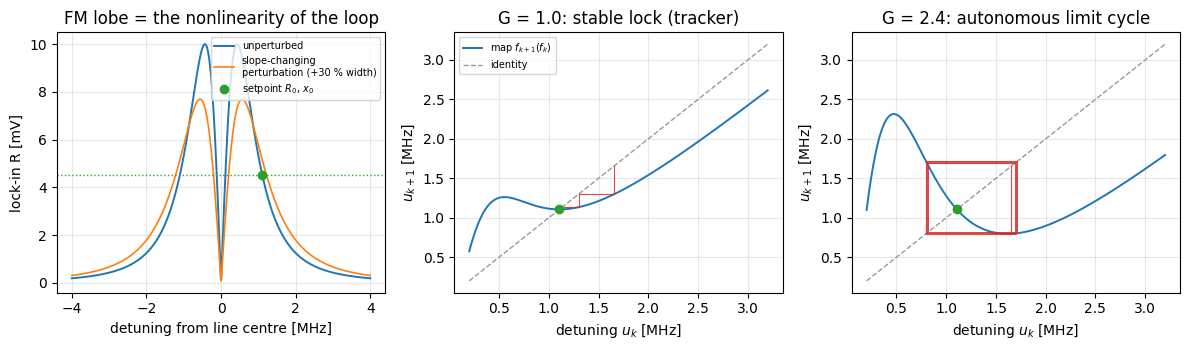

In [2]:
def cobweb(ax, G, n=40, u0=None):
    xs = np.linspace(0.2, 3.2, 600)
    ax.plot(xs, [step(x, G) for x in xs], color="C0", lw=1.4,
            label=r"map $f_{k+1}(f_k)$")
    ax.plot(xs, xs, color="0.6", lw=1, ls="--", label="identity")
    u = u0 if u0 is not None else X0 + 0.55
    px, py = [u], [u]
    for _ in range(n):
        v = step(u, G)
        px += [u, v]
        py += [v, v]
        u = v
    ax.plot(px, py, color="C3", lw=0.8, alpha=0.85)
    ax.plot(X0, X0, "o", color="C2", ms=6)
    ax.set(xlabel=r"detuning $u_k$ [MHz]", ylabel=r"$u_{k+1}$ [MHz]",
           title=f"loop gain G = {G}")
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
x = np.linspace(-4, 4, 1200)
axes[0].plot(x, 1e3 * lobe(x), color="C0", lw=1.4, label="unperturbed")
axes[0].plot(x, 1e3 * lobe(x, 0.3), color="C1", lw=1.2,
             label="slope-changing\nperturbation (+30 % width)")
axes[0].axhline(1e3 * R0, color="C2", ls=":", lw=1)
axes[0].plot(X0, 1e3 * R0, "o", color="C2", label=rf"setpoint $R_0$, $x_0$")
axes[0].set(xlabel="detuning from line centre [MHz]", ylabel="lock-in R [mV]",
            title="FM lobe = the nonlinearity of the loop")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
cobweb(axes[1], 1.0)
axes[1].set_title("G = 1.0: stable lock (tracker)")
cobweb(axes[2], 2.4)
axes[2].set_title("G = 2.4: autonomous limit cycle")
axes[1].legend(fontsize=7)
fig.tight_layout()
fig.show()

### 2.2 Steady state vs gain: the bifurcation diagram

For each gain we iterate the (noise-free) map and plot the frequencies visited
after transients die out. One branch = stable lock; two branches = period-2
self-oscillation; the tree = period doubling to chaos. The onset sits exactly at
$G_{e\!f\!f}=2$. This figure is the "device physics" of the autonomous
sensor.

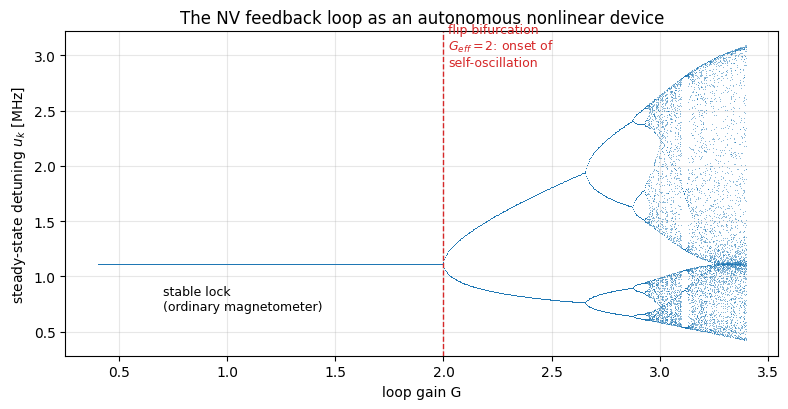

In [3]:
Gs = np.linspace(0.4, 3.4, 800)
fig, ax = plt.subplots(figsize=(8, 4.2))
for G in Gs:
    tail = orbit(G, 500)[-60:]
    ax.plot([G] * len(tail), tail, ",", color="C0", alpha=0.5)
ax.axvline(2.0, color="C3", ls="--", lw=1)
ax.annotate("flip bifurcation\n$G_{eff}=2$: onset of\nself-oscillation",
            (2.02, 2.9), color="C3", fontsize=9)
ax.annotate("stable lock\n(ordinary magnetometer)", (0.7, 0.7), fontsize=9)
ax.annotate("period doubling\n-> chaos", (2.75, 4.4), fontsize=9)
ax.set(xlabel="loop gain G", ylabel="steady-state detuning $u_k$ [MHz]",
       title="The NV feedback loop as an autonomous nonlinear device")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 2.3 Perturbations move the onset

Broadening the resonance line (as a magnetic-field gradient across the ensemble
would) lowers the lobe slope $D_{true}$, so the critical gain
$G_c = 2 D_{cal}/D_{true}$ rises. Operating at fixed $G$ near threshold turns
the *appearance or disappearance of the oscillation* into a sharp detector of
the perturbation.

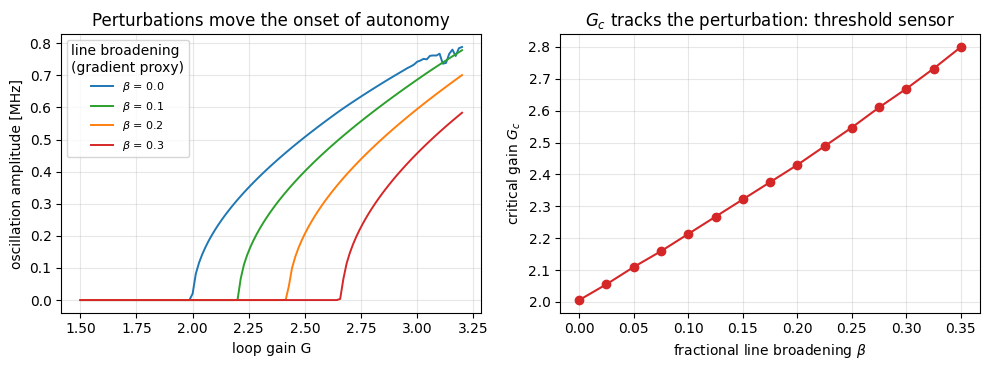

In [4]:
betas = (0.0, 0.1, 0.2, 0.3)
Gs3 = np.linspace(1.5, 3.2, 120)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
for b, c in zip(betas, ("C0", "C2", "C1", "C3")):
    amp = [np.mean([orbit_amp(G, beta=b) for _ in range(1)]) for G in Gs3]
    ax.plot(Gs3, amp, color=c, lw=1.4, label=rf"$\beta$ = {b:.1f}")
ax.set(xlabel="loop gain G", ylabel="oscillation amplitude [MHz]",
       title="Perturbations move the onset of autonomy")
ax.legend(title="line broadening\n(gradient proxy)", fontsize=8)
ax.grid(alpha=0.3)

# threshold vs beta: smallest G with amplitude above a small cut
G_fine = np.linspace(1.6, 3.4, 400)
bet_fine = np.linspace(0, 0.35, 15)
thr = []
for b in bet_fine:
    a = np.array([orbit_amp(G, beta=b) for G in G_fine])
    idx = np.argmax(a > 0.05)
    thr.append(G_fine[idx] if a[idx] > 0.05 else np.nan)
ax2.plot(bet_fine, thr, "o-", color="C3")
ax2.set(xlabel=r"fractional line broadening $\beta$",
        ylabel="critical gain $G_c$",
        title=r"$G_c$ tracks the perturbation: threshold sensor")
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

---
## 3. Experimental results

We ran the protocol on the rig with `smcv/odmr_selfosc_fm_pc.py`: an FM sweep,
hand-picking the flank working point, then the loop at eleven gain values
(0.6 – 3.4, 250 cycles each) and a long statistics run (4000 cycles at
$G = 2.3$). From the run summary: working point 2867.900 MHz, setpoint
$R_0 = 0.102$ mV, calibrated slope $D_{cal} = +0.103$ mV/MHz, cycle time 404 ms.
Note the numbers: the lock-in signal is only ~0.1 mV, i.e. a per-reading
signal-to-noise of roughly 5 — this is a *hard* regime for the demo, and the
data should be read with that in mind.

In [5]:
import csv
import os

# data folder: works whether the notebook runs from proposal/ or the repo root
DATA = "../selfosc_data" if os.path.isdir("../selfosc_data") else "selfosc_data"

def load_gainscan(path):
    runs = {}
    with open(path) as f:
        for row in csv.reader(f):
            if not row or row[0].startswith("#") or row[0] == "gain":
                continue
            runs.setdefault(float(row[0]), []).append(float(row[3]))
    return {g: np.array(v) for g, v in sorted(runs.items())}

def load_stats(path):
    t, fr = [], []
    with open(path) as f:
        for row in csv.reader(f):
            if not row or row[0].startswith("#") or row[0] == "cycle":
                continue
            t.append(float(row[1])); fr.append(float(row[2]))
    return np.array(t), np.array(fr)

def alt_amp(u, blk=32):
    '''Coherent period-2 amplitude: block-median of |mean of (-1)^k (u - <u>)|.
    Amplified noise averages towards 0 inside a block; a real alternating
    limit cycle does not.'''
    u = np.asarray(u, float) - np.mean(u)
    s = ((-1.0) ** np.arange(len(u))) * u
    nb = max(1, len(s) // blk)
    return float(np.median([abs(np.mean(s[i*blk:(i+1)*blk])) for i in range(nb)]))

runs = load_gainscan(f"{DATA}/selfosc_fm_gainscan.csv")
t_st, f_st = load_stats(f"{DATA}/selfosc_fm_stats.csv")

gains = np.array(sorted(runs))
spread = np.array([np.std(runs[g][len(runs[g])//3:]) for g in gains])
a2 = np.array([alt_amp(runs[g][len(runs[g])//3:]) for g in gains])
for g, s, a in zip(gains, spread, a2):
    print(f"G = {g:3.1f}:  spread {1e3*s:7.1f} kHz   period-2 amplitude {1e3*a:6.1f} kHz")

G = 0.6:  spread   126.2 kHz   period-2 amplitude   13.9 kHz
G = 1.0:  spread   374.7 kHz   period-2 amplitude   18.9 kHz
G = 1.4:  spread   338.5 kHz   period-2 amplitude   11.7 kHz
G = 1.8:  spread   497.6 kHz   period-2 amplitude   47.9 kHz
G = 2.0:  spread   622.7 kHz   period-2 amplitude   69.7 kHz
G = 2.1:  spread   646.9 kHz   period-2 amplitude   58.3 kHz
G = 2.2:  spread   713.0 kHz   period-2 amplitude   96.6 kHz
G = 2.4:  spread   714.0 kHz   period-2 amplitude   30.6 kHz
G = 2.7:  spread  1068.2 kHz   period-2 amplitude   84.5 kHz
G = 3.0:  spread  1337.7 kHz   period-2 amplitude   85.4 kHz
G = 3.4:  spread  1456.8 kHz   period-2 amplitude   57.7 kHz


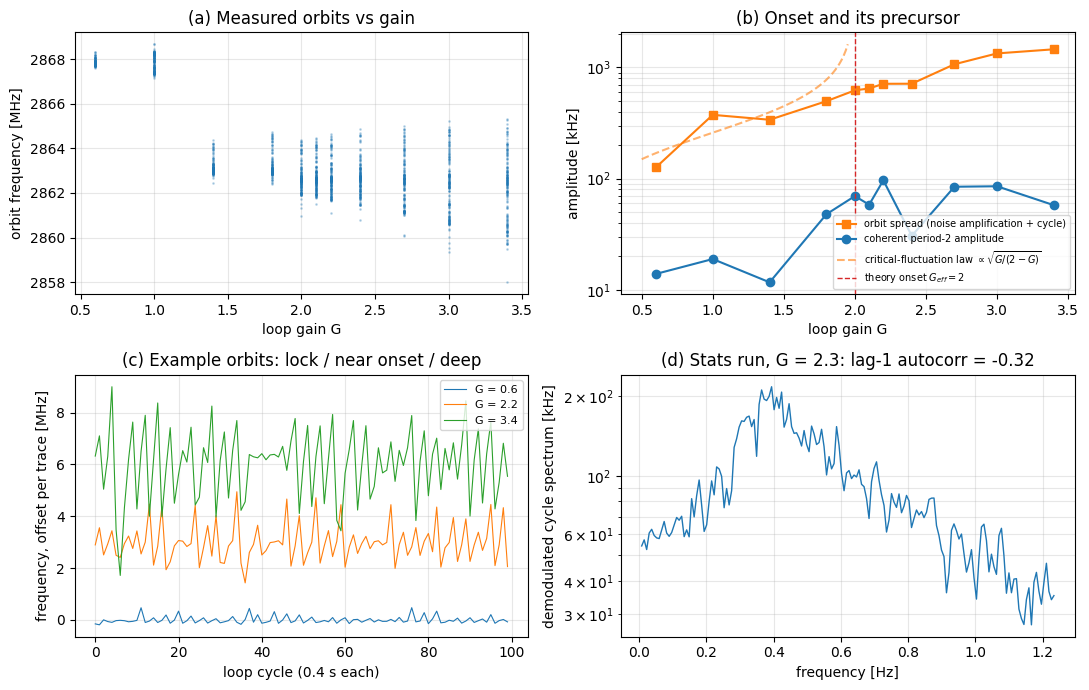

Statistics run: 4000 cycles, std 752 kHz, lag-1 autocorrelation -0.32 (negative = alternating hopping)


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# (a) measured bifurcation diagram
ax = axes[0, 0]
for g in gains:
    tail = runs[g][len(runs[g])//3:]
    ax.plot([g]*len(tail), tail, ".", ms=2, color="C0", alpha=0.25)
ax.set(xlabel="loop gain G", ylabel="orbit frequency [MHz]",
       title="(a) Measured orbits vs gain")
ax.grid(alpha=0.3)

# (b) spread + coherent period-2 amplitude vs gain
ax = axes[0, 1]
ax.semilogy(gains, 1e3*spread, "s-", color="C1",
            label="orbit spread (noise amplification + cycle)")
ax.semilogy(gains, 1e3*a2, "o-", color="C0",
            label="coherent period-2 amplitude")
gg = np.linspace(0.5, 1.95, 100)
mask = gains < 1.6
s0 = float(np.sum(spread[mask]*np.sqrt(gains[mask]/(2-gains[mask])))
           / np.sum(gains[mask]/(2-gains[mask])))
ax.semilogy(gg, 1e3*s0*np.sqrt(gg/(2-gg)), "--", color="C1", alpha=0.6,
            label=r"critical-fluctuation law $\propto\sqrt{G/(2-G)}$")
ax.axvline(2.0, color="C3", ls="--", lw=1, label="theory onset $G_{eff}=2$")
ax.set(xlabel="loop gain G", ylabel="amplitude [kHz]",
       title="(b) Onset and its precursor")
ax.legend(fontsize=7)
ax.grid(alpha=0.3, which="both")

# (c) example orbits
ax = axes[1, 0]
for k, g in enumerate((0.6, 2.2, 3.4)):
    y = runs[g][-100:]
    ax.plot(np.arange(len(y)), y - np.mean(y) + k*3.0, lw=0.8, label=f"G = {g}")
ax.set(xlabel="loop cycle (0.4 s each)",
       ylabel="frequency, offset per trace [MHz]",
       title="(c) Example orbits: lock / near onset / deep")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (d) statistics run: alternation is the period-2 fingerprint
ax = axes[1, 1]
u = f_st - np.mean(f_st)
r1 = float(np.corrcoef(u[:-1], u[1:])[0, 1])
dt = float(np.median(np.diff(t_st)))
s = ((-1.0)**np.arange(len(u))) * u          # demodulate the alternation
seg = len(s)//12
w = np.hanning(seg)
S = [np.abs(np.fft.rfft((s[i*seg:(i+1)*seg]-s[i*seg:(i+1)*seg].mean())*w))**2
     for i in range(12)]
fr_ = np.fft.rfftfreq(seg, dt)
asd = np.sqrt(np.mean(S, axis=0)) / np.sum(w) * 2
ax.semilogy(fr_[1:], 1e3*asd[1:], lw=1.0, color="C0")
ax.set(xlabel="frequency [Hz]", ylabel="demodulated cycle spectrum [kHz]",
       title=f"(d) Stats run, G = 2.3: lag-1 autocorr = {r1:+.2f}")
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()
print(f"Statistics run: {len(u)} cycles, std {1e3*np.std(u):.0f} kHz, "
      f"lag-1 autocorrelation {r1:+.2f} (negative = alternating hopping)")

### 3.1 What the data shows

* **The onset is there, where theory puts it.** The coherent period-2 amplitude
  (panel b, blue) sits at 12–19 kHz for $G \le 1.4$ and jumps to 48–97 kHz from
  $G \approx 1.8$–2.2 — a factor ~4 step across the expected threshold. Because
  this run was *self-calibrated* ($D_{cal}$ measured at the same working point,
  so $D_{true}/D_{cal} \approx 1$), theory predicts $G_c = 2$ exactly; finding
  the jump at 1.8–2.2 is the consistency check passed.
* **The precursor behaves as predicted.** The orbit spread (panel b, orange)
  grows *below* the threshold roughly along the critical-fluctuation law
  $\propto \sqrt{G/(2-G)}$ — the loop amplifying its own readout noise as it
  approaches the bifurcation.
* **The oscillation is real, not just amplified noise.** The 4000-cycle
  statistics run at $G = 2.3$ has a lag-1 autocorrelation of $-0.32$: the
  frequency alternates high–low–high–low far beyond what uncorrelated noise
  allows (null uncertainty $\pm 1/\sqrt{4000} \approx 0.016$). That is the
  period-2 fingerprint, held autonomously for 27 minutes.
* **A side observation in panel (a):** the orbit centre jumps by ~5 MHz
  between the G = 1.0 and G = 1.4 runs — the working point slipped to a
  different part of the line during the session (ambient field/setup
  drift). The dynamical observables (spread, period-2 amplitude) are
  computed per run around each run's own mean, so they are unaffected —
  but it illustrates exactly why threshold-type observables, which are
  insensitive to uniform shifts, are attractive.
* **Honest caveats.** With only ~0.1 mV of lock-in signal (SNR ≈ 5 per
  reading), the period-2 amplitude is noisy and phase slips wash out part of
  the coherent signature (e.g. the dip at G = 2.4 in panel b). The gain grid is
  also coarse. Both are directly fixable — see Sec. 4.

---
## 4. Next experiments

Everything below uses hardware already on the table, in rough priority order.

1. **Raise the signal first.** The whole demo gets easier with a steeper flank:
   increase MW power (deeper dip) and/or laser power, and pick the steepest
   flank point in the picker. Going from 0.1 mV to ~1 mV of lobe signal would
   make every plot above dramatically cleaner. Also worth reducing the settle
   time — at 404 ms/cycle, 250 cycles per gain takes 1.7 min; a faster cycle
   allows finer gain grids and longer statistics in the same session.
2. **MW-power perturbation scan (the first real sensing demo).** Take a
   reference gain scan, then repeat at 2–3 reduced MW powers **without
   recalibrating** — keep the same $f^*$, $R_0$, $D_{cal}$ (essential: if the
   script re-calibrates, $D_{cal}$ tracks $D_{true}$ and $G_c$ stays at 2 by
   construction). Lower power → shallower lobe → smaller $D_{true}$ → the
   onset moves up as $G_c = 2 D_{cal}/D_{true}$. Analyse with
   `analysis/plot_selfosc_fm.py run_ref/ run_p1/ run_p2/`: it extracts $G_c$
   per run (two estimators) and makes the collapse plot ($G_c$ measured vs
   predicted).
3. **Extend and refine the gain grid.** For perturbed runs the onset moves up:
   extend `GAIN_LIST` well past the expected shifted $G_c$ (otherwise the
   supercritical-fit estimator has nothing to fit) and use 0.05–0.1 steps
   around the threshold region.
4. **Magnetic-field gradient.** Same protocol, but move the magnet close so the
   field varies across the ensemble (check the FM sweep: the lobes visibly
   broaden). This is the "differential quantity" data point for the proposal.
   Control experiment: move the magnet *far* (nearly uniform change) — the mean
   locked frequency shifts but $G_c$ should not. That contrast is the symmetry
   argument made experimental.
5. **AC field via cycle statistics.** Wind a few turns of wire near the diamond
   and drive it from the Red Pitaya OUT1 (see `redpitaya/outputsine.py`)
   through a resistor at ~0.5 Hz (the loop Nyquist is 1.24 Hz at the current
   cycle time). Repeat the statistics run coil-on/coil-off and compare the
   demodulated cycle spectra (panel d): the tone should appear as a sideband.
6. **Error bars on $G_c$.** Repeat the reference gain scan ~5 times: the
   scatter of $G_c$, divided by the slope of $G_c$ vs perturbation from step 2,
   gives a quantitative resolution ("this autonomous sensor resolves X % of MW
   power / Y µT of gradient") — the number a referee will look for.

## Limitations

For Gaussian-noise-limited estimation of a *small analog* signal, a well-designed
linear readout with matched filtering is asymptotically optimal; the autonomous
mode does not beat it in raw SNR. Its advantages are of a different kind:
threshold/latching detection (binary output robust to gain and contrast drift),
symmetry-enforced selectivity to differential quantities, internal frequency
conversion of AC signals, and — scientifically — a table-top platform where the
sensing-through-bifurcation concepts of the proposal can be tested and
benchmarked against the same team's NV expertise before being deployed on
mesoscopic autonomous devices.
